In [1]:
import tensorflow as tf
from tensorflow import keras

2024-04-25 13:40:06.108003: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) =fashion_mnist.load_data()

In [3]:
X_train_full.shape

(60000, 28, 28)

In [4]:
X_train_full.dtype

dtype('uint8')

In [5]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] /255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [6]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [7]:
class_names[y_train[0]]

'Coat'

In [8]:
y_train[0]

4

In [9]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

2024-04-25 13:40:09.107271: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [11]:
model.layers

In [12]:
hidden1 = model.layers[1]
model.get_layer('dense') is hidden1

True

In [13]:
weights, biases = hidden1.get_weights()

In [14]:
weights

array([[-0.03836769, -0.06805321,  0.00512182, ..., -0.02944996,
         0.04194156, -0.01156313],
       [-0.0219965 , -0.02407261, -0.06024935, ..., -0.03993123,
        -0.00929118,  0.06432448],
       [ 0.05716541, -0.00558919,  0.02108346, ..., -0.00022772,
         0.06100373, -0.05023016],
       ...,
       [ 0.02399057,  0.03473615, -0.02192741, ..., -0.01771173,
         0.01948164,  0.03567126],
       [ 0.0063256 , -0.00739803,  0.04081262, ...,  0.01919605,
         0.05637586, -0.0351143 ],
       [ 0.06278794,  0.0564146 , -0.05792803, ..., -0.05761502,
         0.02866352, -0.06741057]], dtype=float32)

In [15]:
weights.shape

(784, 300)

In [16]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [17]:
history = model.fit(X_train, y_train, epochs=30,validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 [==============================] - 17s 9ms/step - loss: 0.7066 - accuracy: 0.7711 - val_loss: 0.5132 - val_accuracy: 0.8230
Epoch 2/30
1719/1719 [==============================] - 17s 10ms/step - loss: 0.4898 - accuracy: 0.8289 - val_loss: 0.4359 - val_accuracy: 0.8510
Epoch 3/30
1719/1719 [==============================] - 16s 9ms/step - loss: 0.4451 - accuracy: 0.8450 - val_loss: 0.4229 - val_accuracy: 0.8552
Epoch 4/30
1719/1719 [==============================] - 19s 11ms/step - loss: 0.4172 - accuracy: 0.8523 - val_loss: 0.4583 - val_accuracy: 0.8374
Epoch 5/30
1719/1719 [==============================] - 19s 11ms/step - loss: 0.3971 - accuracy: 0.8602 - val_loss: 0.3784 - val_accuracy: 0.8690
Epoch 6/30
1719/1719 [==============================] - 15s 9ms/step - loss: 0.3798 - accuracy: 0.8659 - val_loss: 0.3745 - val_accuracy: 0.8694
Epoch 7/30
1719/1719 [==============================] - 21s 12ms/step - loss: 0.3675 - accuracy: 0.8701 - val_loss: 0.3696 - va

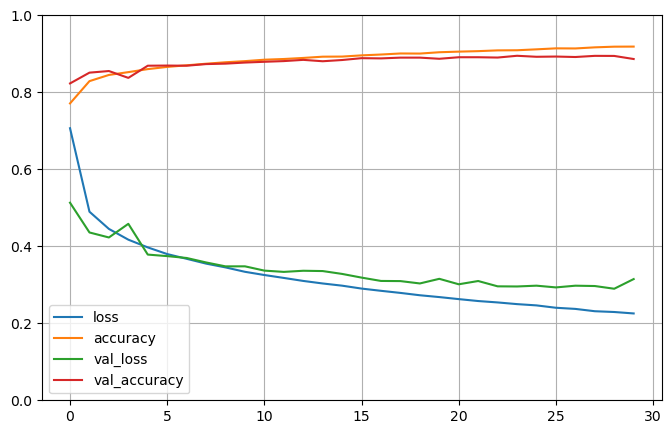

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [19]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 2s 5ms/step - loss: 56.9362 - accuracy: 0.8554


[56.936195373535156, 0.855400025844574]

In [20]:
X_new = X_test[:3]
y_proba = model.predict(X_new)

1/1 [==============================] - 0s 55ms/step


In [21]:
y_proba.round(2)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [24]:
import numpy as np
predict_x=model.predict(X_test) 
classes_x=np.argmax(predict_x,axis=1)

313/313 [==============================] - 0s 1ms/step


In [25]:
y_pred

NameError: name 'y_pred' is not defined